# Step 3 - Baseline Reconstruction

Great-circle interpolation between the last known ADS-B point before the gap
and the first known ADS-B point after the gap.

This is our naive reference - any improved method must beat it.

In [15]:
from pathlib import Path
import sys
sys.path.insert(0, str(Path("../src").resolve()))
sys.path.insert(0, str(Path("../noel_part").resolve()))

import pandas as pd
import numpy as np
import json
from pyproj import Geod

BASE_DIR  = Path("../noel_part")
CLEAN_DIR = BASE_DIR / "cleaned_data_final"
RECON_DIR = BASE_DIR / "final_reconstructions"
OUT_DIR   = Path("../outputs")
OUT_DIR.mkdir(exist_ok=True)

geod = Geod(ellps="WGS84")
flights = [f for s in sorted(CLEAN_DIR.iterdir()) if s.is_dir()
           for f in sorted(s.iterdir()) if f.is_dir()]
print(f"Flights available: {len(flights)}")

Flights available: 2149


## 3a. How the baseline works

For a gap between time $t_0$ (last ADS-B before) and $t_1$ (first ADS-B after):

1. Compute the great-circle arc from the last known position to the first known position after the gap
2. Interpolate $n$ evenly spaced points along this arc
3. Blend a forward arc with a backward arc linearly

This is implemented in `src/step3_baseline.py` and `noel_part/reconstruction.py`.

## 3b. Run baseline on a sample flight

In [16]:
# -- 3b. Run baseline on a sample flight --------------------------------------
import sys
from pathlib import Path
import matplotlib.pyplot as plt

# Add both noel_part and notebook dirs to path before any chdir
_notebook_dir = Path(".").resolve()
sys.path.insert(0, str((_notebook_dir / "../noel_part").resolve()))
sys.path.insert(0, str(_notebook_dir))

import os
os.chdir(Path("../noel_part").resolve())

from step3_baseline import reconstruct_gap_baseline
import pandas as pd
import numpy as np

# Re-resolve flights after chdir
CLEAN_DIR = Path("cleaned_data_final")
flights = [f for s in sorted(CLEAN_DIR.iterdir()) if s.is_dir()
           for f in sorted(s.iterdir()) if f.is_dir()]

sample = flights[0]
bef  = pd.read_parquet(sample / "adsb_before.parquet")
adsc = pd.read_parquet(sample / "adsc.parquet")
aft  = pd.read_parquet(sample / "adsb_after.parquet")

recon = reconstruct_gap_baseline(bef, aft)
print(f"Gap: {len(recon)} reconstructed steps")
print(f"From: lat={bef['latitude'].iloc[-1]:.3f}, lon={bef['longitude'].iloc[-1]:.3f}")
print(f"To  : lat={aft['latitude'].iloc[0]:.3f},  lon={aft['longitude'].iloc[0]:.3f}")
display(recon[["timestamp","latitude","longitude","altitude"]].head(5))


Gap: 919 reconstructed steps
From: lat=54.458, lon=-14.150
To  : lat=46.926,  lon=-62.602


,timestamp,latitude,longitude,altitude
0,2023-08-10 06:56:45,54.461902,-14.207803,9753.600000
1,2023-08-10 06:57:00,54.465555,-14.265307,9754.264052
2,2023-08-10 06:57:15,54.469181,-14.322820,9754.928105
3,2023-08-10 06:57:30,54.472780,-14.380344,9755.592157
4,2023-08-10 06:57:45,54.476351,-14.437878,9756.256209


## 3c. Evaluate baseline against ADS-C ground truth

In [17]:
# -- 3c. Evaluate baseline against ADS-C ground truth -------------------------
import sys, os
from pathlib import Path

# Compute absolute path to notebooks folder BEFORE any chdir
NOTEBOOKS_DIR = Path(os.path.abspath("")).resolve()
if NOTEBOOKS_DIR.name != "notebooks":
    # We already chdired to noel_part, find notebooks as sibling
    NOTEBOOKS_DIR = NOTEBOOKS_DIR.parent / "notebook"

print(f"Notebooks dir: {NOTEBOOKS_DIR}")
print(f"Exists: {NOTEBOOKS_DIR.exists()}")

# Add to path
if str(NOTEBOOKS_DIR) not in sys.path:
    sys.path.insert(0, str(NOTEBOOKS_DIR))

# Also try adding the current directory
if os.getcwd() not in sys.path:
    sys.path.insert(0, os.getcwd())

print(f"sys.path[0]: {sys.path[0]}")
print(f"sys.path[1]: {sys.path[1]}")

Notebooks dir: C:\Users\marko\Desktop\AeroML3(og)\AeroML3\notebook
Exists: True
sys.path[0]: C:\Users\marko\Desktop\AeroML3(og)\AeroML3\noel_part
sys.path[1]: C:\Users\marko\Desktop\AeroML3(og)\AeroML3\noel_part


In [18]:
# Nearest-neighbour 2D haversine error -- same metric as 05_evaluate

def error_km(recon_df, truth_df):
    "Mean of each ADS-C waypoint's distance to its nearest reconstruction point (km)."
    if len(truth_df) == 0 or len(recon_df) == 0:
        return np.nan
    lat1 = np.radians(truth_df['latitude'].values[:, None])
    lon1 = np.radians(truth_df['longitude'].values[:, None])
    lat2 = np.radians(recon_df['latitude'].values[None, :])
    lon2 = np.radians(recon_df['longitude'].values[None, :])
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    return float(2 * 6_371.0 * np.arcsin(np.sqrt(np.clip(a, 0, 1))).min(axis=1).mean())

# Filter ADS-C to waypoints inside the gap only
t0 = bef['timestamp'].iloc[-1]
t1 = aft['timestamp'].iloc[0]
if hasattr(t0, 'tzinfo') and t0.tzinfo is not None:
    t0 = t0.replace(tzinfo=None)
if hasattr(t1, 'tzinfo') and t1.tzinfo is not None:
    t1 = t1.replace(tzinfo=None)
adsc_ts = adsc['timestamp']
if hasattr(adsc_ts.iloc[0], 'tzinfo') and adsc_ts.iloc[0].tzinfo is not None:
    adsc_ts = adsc_ts.dt.tz_localize(None)
adsc_gap = adsc[(adsc_ts > t0) & (adsc_ts < t1)].reset_index(drop=True)

print(f'ADS-C waypoints inside gap: {len(adsc_gap)}')

baseline_err = error_km(recon, adsc_gap)
print(f'Baseline mean nearest-neighbour error: {baseline_err:.3f} km')


ADS-C waypoints inside gap: 444
Baseline mean nearest-neighbour error: 101.907 km


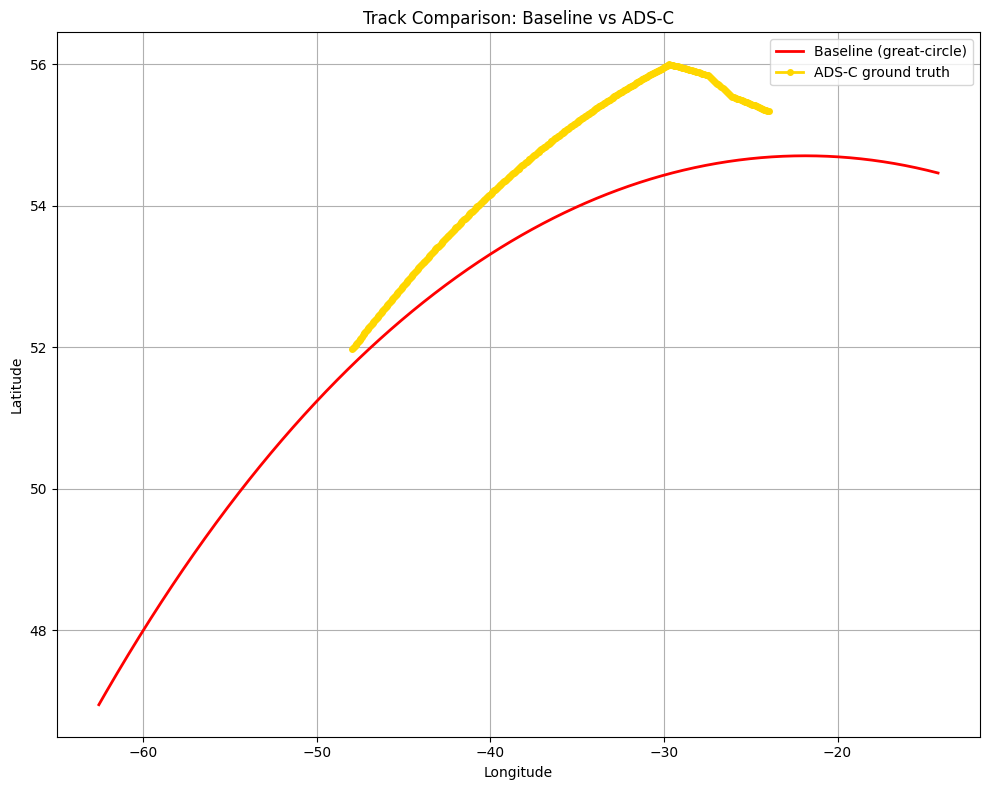

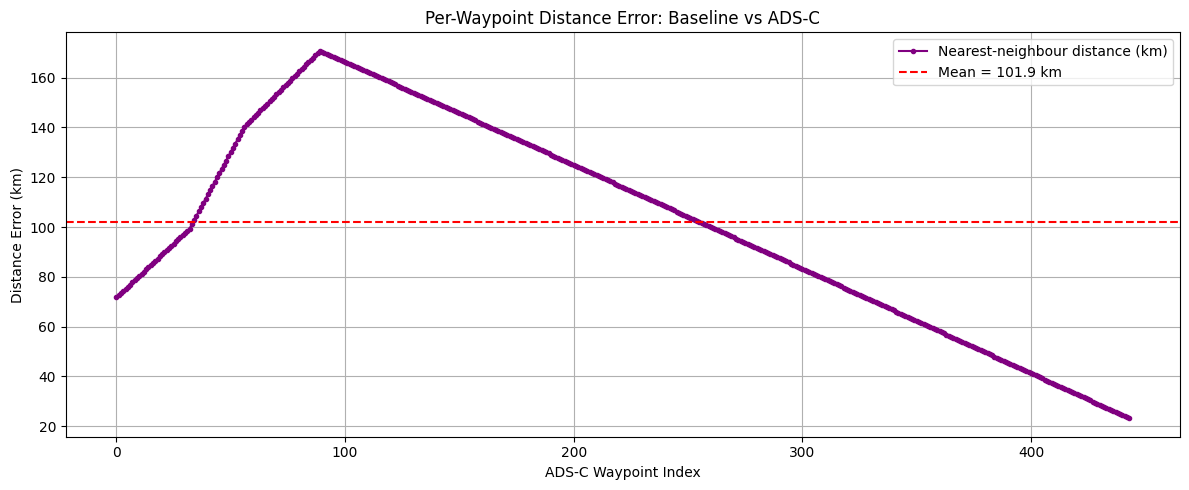

In [19]:
import matplotlib.pyplot as plt
import numpy as np

# -- Track comparison: Baseline vs ADS-C ----------------------------------
plt.figure(figsize=(10, 8))
plt.plot(recon["longitude"], recon["latitude"],
         label="Baseline (great-circle)", color="red", linewidth=2)
plt.plot(adsc_gap["longitude"], adsc_gap["latitude"],
         label="ADS-C ground truth", color="gold", linewidth=2, marker="o", markersize=4)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Track Comparison: Baseline vs ADS-C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# -- Nearest-neighbour distance per ADS-C waypoint ------------------------
lat1 = np.radians(adsc_gap["latitude"].values[:, None])
lon1 = np.radians(adsc_gap["longitude"].values[:, None])
lat2 = np.radians(recon["latitude"].values[None, :])
lon2 = np.radians(recon["longitude"].values[None, :])
dlat = lat2 - lat1; dlon = lon2 - lon1
a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
nn_dist_km = 2 * 6371.0 * np.arcsin(np.sqrt(np.clip(a, 0, 1))).min(axis=1)

plt.figure(figsize=(12, 5))
plt.plot(range(len(nn_dist_km)), nn_dist_km,
         label="Nearest-neighbour distance (km)", color="purple", marker="o", markersize=3)
plt.axhline(nn_dist_km.mean(), color="red", linestyle="--",
            label=f"Mean = {nn_dist_km.mean():.1f} km")
plt.title("Per-Waypoint Distance Error: Baseline vs ADS-C")
plt.xlabel("ADS-C Waypoint Index")
plt.ylabel("Distance Error (km)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


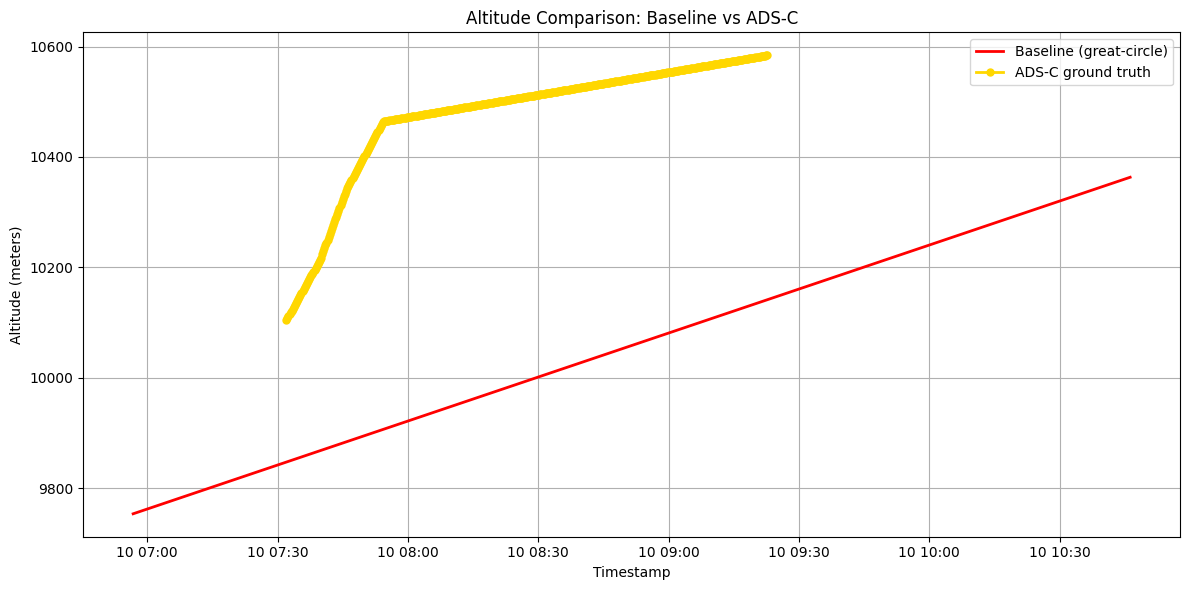

In [20]:
import matplotlib.pyplot as plt

# -- Altitude comparison: Baseline vs ADS-C -------------------------------
plt.figure(figsize=(12, 6))
plt.plot(recon["timestamp"], recon["altitude"],
         label="Baseline (great-circle)", color="red", linewidth=2)
if "altitude" in adsc_gap.columns and len(adsc_gap) > 0:
    adsc_ts = adsc_gap["timestamp"]
    if hasattr(adsc_ts.iloc[0], "tzinfo") and adsc_ts.iloc[0].tzinfo is not None:
        adsc_ts = adsc_ts.dt.tz_localize(None)
    plt.plot(adsc_ts, adsc_gap["altitude"],
             label="ADS-C ground truth", color="gold", linewidth=2,
             marker="o", markersize=5)
plt.xlabel("Timestamp")
plt.ylabel("Altitude (meters)")
plt.title("Altitude Comparison: Baseline vs ADS-C")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## 3d. Export GeoJSON for geojson.io

In [21]:
import json
from pathlib import Path

# OUT_DIR: robust after chdir to noel_part
_out = Path("../outputs")
_out.mkdir(exist_ok=True)

sample      = flights[0]
step_name   = sample.parent.name
flight_name = sample.name

bef  = pd.read_parquet(sample / "adsb_before.parquet")
adsc = pd.read_parquet(sample / "adsc.parquet")
aft  = pd.read_parquet(sample / "adsb_after.parquet")
recon = reconstruct_gap_baseline(bef, aft)

def _line(lons, lats, props):
    coords = [[float(lo), float(la)] for lo, la in zip(lons, lats)
              if np.isfinite(float(lo)) and np.isfinite(float(la))]
    if len(coords) < 2:
        return None
    return {"type": "Feature", "properties": props,
            "geometry": {"type": "LineString", "coordinates": coords}}

features = [
    _line(bef["longitude"],   bef["latitude"],
          {"label": "ADS-B before",           "stroke": "#888888", "stroke-width": 2, "stroke-opacity": 0.8}),
    _line(aft["longitude"],   aft["latitude"],
          {"label": "ADS-B after",            "stroke": "#888888", "stroke-width": 2, "stroke-opacity": 0.8}),
    _line(adsc["longitude"],  adsc["latitude"],
          {"label": "ADS-C ground truth",     "stroke": "#FFC107", "stroke-width": 3, "stroke-opacity": 1.0}),
    _line(recon["longitude"], recon["latitude"],
          {"label": "Baseline (great-circle)","stroke": "#F44336", "stroke-width": 2, "stroke-opacity": 0.9}),
]

features = [f for f in features if f]
fc  = {"type": "FeatureCollection", "features": features}
out = _out / f"{flight_name}_baseline.geojson"
out.write_text(json.dumps(fc, indent=2), encoding="utf-8")
print(f"GeoJSON saved -> {out}")
print("Open at https://geojson.io")
print()
print("Legend:")
print("  Grey   = ADS-B track (before + after gap)")
print("  Yellow = ADS-C ground truth")
print("  Red    = Baseline (great-circle interpolation)")


GeoJSON saved -> ..\outputs\20230810_4ba959_073209_092245_baseline.geojson
Open at https://geojson.io

Legend:
  Grey   = ADS-B track (before + after gap)
  Yellow = ADS-C ground truth
  Red    = Baseline (great-circle interpolation)
